# Carbon efficient charging of battery powered loads

Every year the pressure to decarbonise mounts. This is a key driver in the adoption of electric vehicles. Despite their rising popularity, a common argument against their use is that the majority of power used to charge them still comes from fossil fuels. (We will put aside the obvious rejoinder that fossil fuel power plants are far more efficient than the average car's internal combustion engine.) The eco-conscious consumer might then proudly reply that she purchases clean energy from one of the many companies now catering to environmentally minded consumers. However, the clean energy thus obtained might not be as green as it seems. The system runs on REGOs and PPAs that ensure that consumed energy is, at some point in time (perhaps weeks from the date of consumption), generated by a green energy source. Crucially, the temporal mismatch means that an eco-conscious consumer might be drawing very dirty energy from the grid despite their commitment to an eco-friendly energy provider.

So what is the eco-warrior to do? Energy on the grid is fungible, but the mix at any given moment is known. What is more, NESO publishes a forecast predicting the carbon intensity of electricity generated in Great Britain. It seems possible that the eco-warrior could use this information to charge their EV at times when their consumption is carbon-optimal — on top of being contractually carbon-free.

# Findings

I investigate two seperate questions: 

1. What is an upper bound for how much carbon our eco-warrior could save given the forecast currently published? Would it even be worth doing?
2. Would this be improved by a better forecast?

To answer the first question, I find that given a deterministic discharge (an idealised driver who always known exactly when he's going to drive and how far) schedule an average car owner can expect to reduce their carbon footprint ~ 42-48% over the year. For the tested case (30km of driving daily — about the UK average) this amounts to about 200 kg of carbon per car per year. 

There are roughly 2 million electric cars in the UK. So an upper bound for projected annual savings from carbon-optimisation could be ~400,000t of C0_2 or more than 1.4M <sup>1</sup> London-Rome flights worth of carbon.

The answer to the second question depends on how one defines a better forecast. I find that given the current 48 hour NESO forecast, a Model Predictive Control (MPC) policy already captures ~93% of the possible gains for a 48 hour forecast, indicating limited marginal improvement from increasing forecast accuracy. However, for larger batter EVs the policy only captures ~60-70% of the optimal strategy given full clairvoyance. This suggests that increasing forecast length might yield significant improvements (another 100 kg of carbon per car per year or 700,000 London-Rome flights!)

<small>[1] according to https://www.atmosfair.de/en/offset/flight/ the average LGW-FCO flight costs about 278kg of carbon </small>

## Problem Setup

### Data

The analysis uses NESO's historical carbon intensity dataset for Great Britain, which provides both realised half-hourly carbon intensity and rolling forecasts at 24-hour and 48-hour horizons. The 48-hour forecast is used throughout. This choice is motivated by the findings: forecast horizon is the dominant lever for improving carbon savings, so the longest available horizon is the natural choice for establishing an upper bound on achievable savings.

I extracted queried data from 2025-01-01 to 2026-01-01 — exactly 1 year of half-hourly observations at the end of each settlement period.

### Load Profiles

Four loads are tested, spanning a range of battery capacities and usage patterns:

| Load | Capacity | Max charge rate | Availability | Discharge profile |
|------|----------|----------------|--------------|-------------------|
| EV (home only) | 100 kWh | 10 kW | 00:00–08:00, 18:30–24:00 | 08:30–09:00 at 6 kW; 17:45–18:30 at 6 kW |
| EV (home + work, large) | 100 kWh | 10 kW | 00:00–08:00, 09:00–17:30, 18:30–24:00 | as above |
| EV (home + work, small) | 50 kWh | 10 kW | 00:00–08:00, 09:00–17:30, 18:30–24:00 | as above |
| Laptop | 0.1 kWh | 60 W | 00:00–10:00, 17:00–24:00 | 08:00–12:00 at 20 W; 13:00–16:00 at 20 W; 18:00–20:00 at 60 W |

The EV discharge profile corresponds to approximately 30 km of daily driving — roughly the UK average. All loads use a charge efficiency of 95%. The home-only EV represents a driver with no workplace charging access; the home+work variants represent a driver with a charger at both locations, giving the optimiser more flexibility.

### Formulation

We restrict the problem to deterministic discharge schedules. Maximum charging speeds are fixed, and batteries are modelled as energy buckets with no charge/discharge simultaneity constraint. These simplifications are standard in the demand-side management literature and do not materially affect the qualitative conclusions.

Let $x(t)$ be the load state of charge, $S$ the maximum charging rate, $C$ the capacity, $a(t) \in \{0,1\}$ the charging availability indicator, $d(t)$ the deterministic discharge power, and $c(t)$ the carbon intensity of grid electricity. The continuous optimisation problem is:

$$\begin{aligned}
x(t) &= x_{\text{init}} + \int_{t_0}^{t} Su(\tau) - d(\tau)\, d\tau \\
\min_{u(t)} \quad & \int_{t_0}^T u(t)\, c(t)\, dt \\
\text{subject to:} \quad & u(t) \in [0,\, a(t)] \\
& 0 \leq x(t) \leq C
\end{aligned}$$

Since $c(t)$ is piecewise constant over settlement periods and discharges are constant power, the optimal control is also piecewise constant. The continuous problem reduces exactly to a finite-dimensional LP:

$$\begin{aligned}
\min_{u_0,\ldots,u_{N-1}} \quad & \sum_{k=0}^{N-1} c_k\, u_k\, \Delta_k \\
\text{subject to:} \quad & x_{k+1} = x_k + (Su_k - \bar{d}_k)\,\Delta_k \quad & k = 0,\ldots,N-1 \\
& 0 \leq x_k \leq C \quad & k = 0,\ldots,N \\
& 0 \leq u_k \leq a_k \quad & k = 0,\ldots,N-1 \\
& x_0 = x_{\text{init}}
\end{aligned}$$

where $\Delta_k = t_{k+1} - t_k$ and breakpoints $t_k$ coincide with settlement period boundaries, discharge events, and availability transitions. Let $\hat{\mathbf{u}}$ denote the optimal control vector.

```python
# [LP solver implementation — see battery/optimisers.py]
```

### Policies

Three policies are evaluated and compared against a naive baseline:

**Naive.** The load charges at maximum rate whenever available, subject to capacity constraints. This represents the default behaviour of an unoptimised charger — charge until full, stay full.

**MPC (optimal).** At each new forecast issue time (every 30 minutes), the LP above is solved over the available forecast horizon. The first control action is applied, and the process repeats when the next forecast arrives. This is the standard receding-horizon approach from optimal control: always act on the best currently available information.

**Clairvoyant.** The LP is solved once over the entire year using realised carbon intensity — perfect foresight. This is not achievable in practice; it defines the theoretical upper bound on savings.

**Clairvoyant MPC.** MPC applied with a perfect 48-hour forecast — i.e. the forecast error is zero but the horizon remains 48 hours. This isolates the contribution of forecast accuracy from forecast length.

```python
# [Policy simulation loop — see src/simulate.py]
```

The gap between MPC and clairvoyant MPC measures the cost of forecast inaccuracy. The gap between clairvoyant MPC and clairvoyant measures the cost of finite horizon length. Together they decompose the value of information, which is the subject of the analysis below.

# MPC in Action

Before evaluating performance across the full year, it is instructive to examine what the MPC policy actually does. The following plot shows a representative week of the optimal charging trajectory alongside the carbon intensity forecast — illustrating how the scheduler concentrates charging in low-carbon windows and defers it away from peaks.

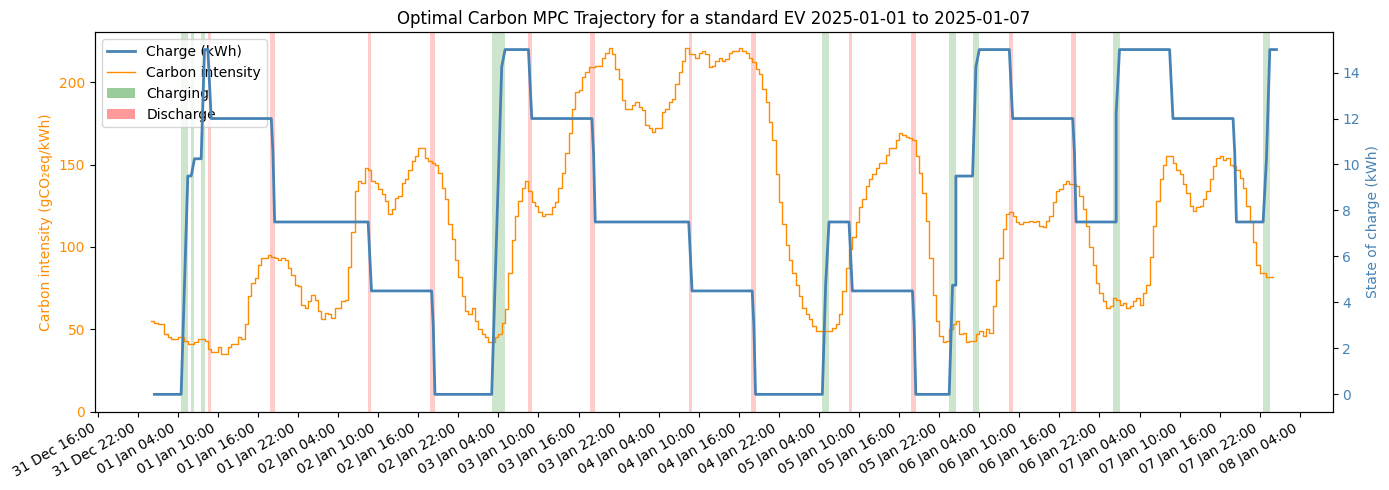

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from datetime import datetime, date, time, timedelta
from battery import recurring_discharge

RESULTS_PATH = Path().resolve() / "Data" / "results"
EV_SCHEDULE = [
    (time(8, 30), time(9, 0), 6),
    (time(17, 45), time(18, 30), 6),
]
START_DATE = date(2025, 1, 1)
END_DATE = date(2025, 1, 7)
DT = (END_DATE-START_DATE)

df_demo = pd.read_parquet(RESULTS_PATH/ "ev_home_only_48h.parquet")
mask = (df_demo["t"].dt.date >= START_DATE) & (df_demo["t"].dt.date <= END_DATE)
df_demo = df_demo[mask]
t = pd.to_datetime(df_demo["t"])
optimal_charge = df_demo["charge_optimal"]
carbon_intensity = df_demo["actual_intensity"]
u = df_demo["u_optimal"]
half_hour = pd.Timedelta("30min")
schedule = recurring_discharge(EV_SCHEDULE, datetime.combine(START_DATE, time.min), DT)

fig, ax1 = plt.subplots(figsize=(14, 5))

# ── Carbon intensity (left axis) ─────────────────────────────────────────────
ax1.step(t, carbon_intensity, where="post",
         color="darkorange", linewidth=1, label="Carbon intensity")
ax1.set_ylabel("Carbon intensity (gCO₂eq/kWh)", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax1.set_ylim(0, None)

# ── Charge state (right axis) ─────────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(t+timedelta(minutes=30), optimal_charge, color="steelblue", linewidth=2)
ax2.set_ylabel("State of charge (kWh)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# ── Charging periods (green) ──────────────────────────────────────────────────
for i in u.index[u.values > 0]:
    ax1.axvspan(t[i], t[i] + timedelta(minutes=30), alpha=0.2, color="green", linewidth=0)

# ── Discharge periods (red) ───────────────────────────────────────────────────
for d in schedule:
    ax1.axvspan(
        d.start_time,
        d.end_time,
        alpha=0.2, color="red", linewidth=0,
    )

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
fig.autofmt_xdate()

legend = [
    plt.Line2D([0], [0], color="steelblue", linewidth=2, label="Charge (kWh)"),
    plt.Line2D([0], [0], color="darkorange", linewidth=1, label="Carbon intensity"),
    mpatches.Patch(facecolor="green", alpha=0.4, label="Charging"),
    mpatches.Patch(facecolor="red",   alpha=0.4, label="Discharge"),
]
ax1.legend(handles=legend, loc="upper left")
ax1.set_title("Optimal Carbon MPC Trajectory for a standard EV 2025-01-01 to 2025-01-07")
plt.tight_layout()
plt.show()

# Results

## How much carbon does MPC save?

Carbon-aware MPC scheduling reduces the annual carbon footprint of EV charging by 43–47% relative to a naive always-on policy, saving approximately 200 kgCO₂ per car per year across all three EV configurations. Wider charging availability compounds the gains: a driver with access to both home and workplace charging saves 47.2% versus 43.1% for home charging alone, with near-identical absolute savings (~200 kg) despite a lower naive baseline.

Notably, the small-capacity EV (50 kWh) achieves near-identical savings to its 100 kWh counterpart (46.9% vs 47.2%). This is expected: at a discharge rate of 6 kW twice daily, the full 50 kWh capacity is never called upon within the 48-hour forecast horizon, so the capacity constraint never binds and the optimiser behaves identically to the larger battery case. Greater battery capacity only translates into greater flexibility — the ability to delay charging into lower-carbon slots further in the future — when the forecast horizon is long enough to exploit it. The capacity difference would only manifest at longer forecast horizons, as demonstrated in the second part of the analysis.

The laptop, with its small battery and near-continuous use, serves as a limiting case at 13.6%. The gains are driven by the ratio of battery capacity to discharge obligation: where that ratio is small, the optimiser has little room to manoeuvre.

In [2]:
from pathlib import Path
import pandas as pd
from datetime import timedelta

evhome48, evwork_s48, evwork48, ltop48 = "ev_home_only_48h.parquet", "ev_home_work_small_cap_48h.parquet", "ev_home_work_48h.parquet", "laptop_48h.parquet"
optimisers = ["naive", "optimal", "clairvoyant", "clair_mpc"]

req_cols = []
for o in optimisers:
    req_cols.append(f"energy_drawn_{o}")
    req_cols.append(f"carbon_cost_{o}")

df_evhome48 = pd.read_parquet(RESULTS_PATH / evhome48).set_index("t")[req_cols]
df_evwork48 = pd.read_parquet(RESULTS_PATH / evwork48).set_index("t")[req_cols]
df_evwork_s48 = pd.read_parquet(RESULTS_PATH / evwork_s48).set_index("t")[req_cols]
df_ltop48 = pd.read_parquet(RESULTS_PATH / ltop48).set_index("t")[req_cols]

loads = [
    ("EV home only", df_evhome48),
    ("EV home + work", df_evwork48),
    ("small capacity EV home + work", df_evwork_s48),
    ("laptop", df_ltop48),
]

rows = []
for label, load in loads:
    cc_optimal = load['carbon_cost_optimal'].sum()
    cc_naive = load['carbon_cost_naive'].sum()
    cc_saved = cc_naive - cc_optimal
    rows.append({
        "Load": label,
        "Naive (kgCO₂)": cc_naive / 1000,
        "Optimal (kgCO₂)": cc_optimal / 1000,
        "Saved (kgCO₂)": cc_saved / 1000,
        "% Saved": cc_saved / cc_naive * 100,
    })

df_savings = pd.DataFrame(rows).set_index("Load")
df_savings.style.format({
    "Naive (kgCO₂)": "{:.1f}",
    "Optimal (kgCO₂)": "{:.1f}",
    "Saved (kgCO₂)": "{:.1f}",
    "% Saved": "{:.1f}%",
})


,Naive (kgCO₂),Optimal (kgCO₂),Saved (kgCO₂),% Saved
Load,,,,
EV home only,471.8,268.4,203.3,43.1%
EV home + work,426.7,225.3,201.4,47.2%
small capacity EV home + work,424.6,225.3,199.4,46.9%
laptop,15.3,13.3,2.1,13.6%


# Savings Over Time

Savings are consistently substantial over the year, rather than being the result of a few timely optimisation periods.

A rolling 30-day average detects a mild seasonal pattern in carbon saved, consistent with increasing carbon intensity variance in winter. However, a Ljung-Box test fails to reject the null of no autocorrelation for weekly aggregated data, and a stationary block bootstrap with data-determined optimal block length returns a block length of one week across all EV loads and two weeks for the laptop — roughly equivalent to an iid bootstrap in both cases. This justifies the use of simple standard errors despite the mild seasonality.
These data are presented in the [appendix](#appendix)

Daily carbon savings are not used as the unit of analysis because the MPC optimiser operates across day boundaries, meaning a charging decision made on day N to exploit a low-carbon window in the early hours of day $N+1$ is attributed to day $N+1$, creating artificial variance in the daily series. Weekly aggregation is used throughout on the heuristic grounds that spillover effects are small relative to a week's total carbon cost and symmetric across week boundaries — contributing noise but no bias to the weekly mean.

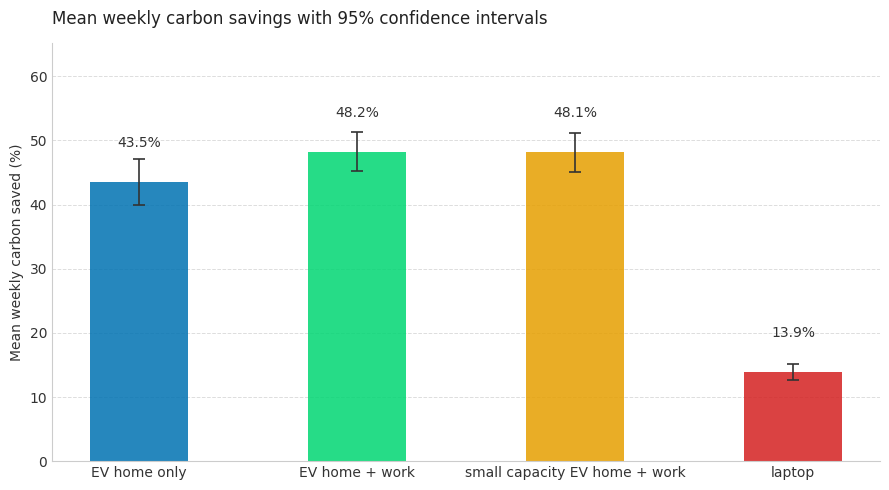

In [5]:
df_evhome48a = df_evhome48.resample("W", label="right").sum()
df_evwork48a = df_evwork48.resample("W", label="right").sum()
df_evwork_s48a = df_evwork_s48.resample("W", label="right").sum()
df_ltop48a = df_ltop48.resample("W", label="right").sum()

loads_aggregated = [
    ("EV home only", df_evhome48a),
    ("EV home + work", df_evwork48a),
    ("small capacity EV home + work", df_evwork_s48a),
    ("laptop", df_ltop48a),
]

labels = [l for l, _ in loads_aggregated]
colors = ["#0072B2", "#00D672", "#E69F00", "#D42121"]

weekly_pct_savings = [
    (load["carbon_cost_naive"] - load["carbon_cost_optimal"]) * 100 / load["carbon_cost_naive"]
    for _, load in loads_aggregated
]

means = [s.mean() for s in weekly_pct_savings]
sems  = [s.sem()  for s in weekly_pct_savings]
cis   = [1.96 * se for se in sems]

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=cis, width=0.45, color=colors,
              alpha=0.85, capsize=4,
              error_kw={"elinewidth": 1.2, "ecolor": "#333333", "capthick": 1.2})

# Annotate bars with mean values
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{mean:.1f}%", ha="center", va="bottom",
            fontsize=10, color="#333333")

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Grid
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, color="#dddddd", zorder=0)
ax.set_axisbelow(True)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, color="#333333")
ax.set_ylabel("Mean weekly carbon saved (%)", fontsize=10, color="#333333")
ax.set_ylim(0, max(means) * 1.35)
ax.tick_params(axis="both", colors="#333333", length=0)

ax.set_title("Mean weekly carbon savings with 95% confidence intervals",
             fontsize=12, color="#222222", pad=14, loc="left")

plt.tight_layout()
plt.show()

## Forecast Quality
Could a better forecast yield greater carbon savings? To answer this, I compare the MPC policy against two benchmarks. The clairvoyant policy assumes perfect foresight over the entire year — the theoretical upper bound on achievable savings. The clairvoyant MPC policy assumes a perfect 48-hour forecast but retains the receding-horizon structure of MPC. The gap between MPC and clairvoyant MPC isolates the cost of forecast inaccuracy; the gap between clairvoyant MPC and clairvoyant isolates the cost of finite horizon length. These two gaps together decompose the value of perfect information.

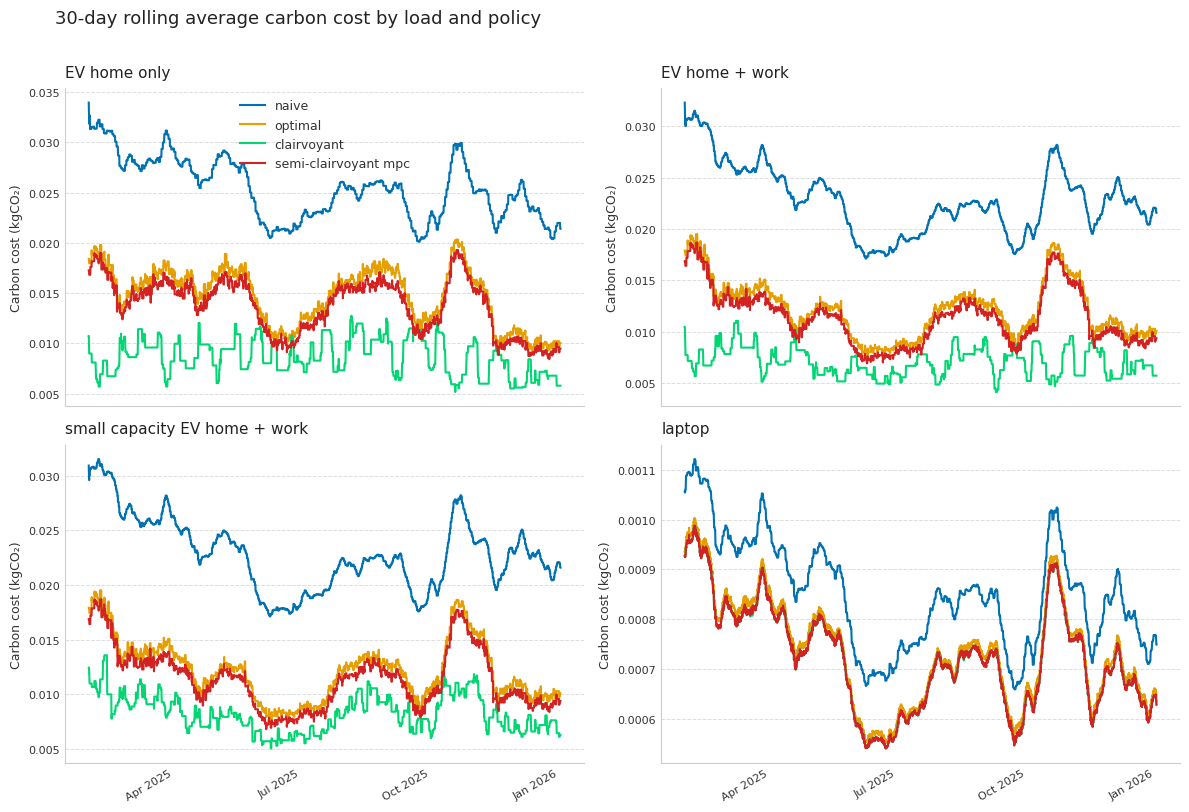

In [9]:
metrics = [
    ("naive", "carbon_cost_naive", "#0072B2"),
    ("optimal", "carbon_cost_optimal", "#E69F00"),
    ("clairvoyant", "carbon_cost_clairvoyant", "#00D672"),
    ("semi-clairvoyant mpc", "carbon_cost_clair_mpc", "#D42121")
]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axs = [axs[0][0], axs[0][1], axs[1][0], axs[1][1]]

for i, (title, load) in enumerate(loads):
    rolling_avg = load.rolling(window="30D").mean()[
        load.index > load.index.min() + timedelta(days=30)
    ]
    for label, key, c in metrics:
        axs[i].plot(rolling_avg.index, rolling_avg[key] / 1000,
                    color=c, label=label, linewidth=1.5)

    axs[i].set_title(title, fontsize=11, color="#222222", loc="left", pad=8)
    axs[i].set_ylabel("Carbon cost (kgCO₂)", fontsize=9, color="#333333")
    axs[i].spines["top"].set_visible(False)
    axs[i].spines["right"].set_visible(False)
    axs[i].spines["left"].set_color("#cccccc")
    axs[i].spines["bottom"].set_color("#cccccc")
    axs[i].yaxis.grid(True, linestyle="--", linewidth=0.7, color="#dddddd", zorder=0)
    axs[i].set_axisbelow(True)
    axs[i].tick_params(axis="both", colors="#333333", length=0, labelsize=8)
    axs[i].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axs[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axs[0].legend(frameon=False, fontsize=9, labelcolor="#333333")

fig.suptitle("30-day rolling average carbon cost by load and policy",
             fontsize=13, color="#222222", x=0.05, ha="left", y=1.01)

fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The MPC schedule (orange) tracks the clairvoyant MPC schedule (red) closely across all four loads, indicating that forecast inaccuracy accounts for little of the gap between MPC and the theoretical optimum. The more informative divergence is between loads: for the laptop, MPC also tracks the fully clairvoyant policy (green), whereas for the larger-battery EVs a persistent gap remains. Since MPC already matches clairvoyant MPC, this gap is attributable to horizon length rather than accuracy: a larger battery can exploit low-carbon periods beyond the 48-hour window, but the optimiser cannot see far enough ahead to do so.

To quantify what the plots suggest, I define two efficiency metrics and one absolute metric. Let $S$ denote the carbon saved by the MPC policy relative to naive, $S_{\text{clairvoyant}}$ the savings under full clairvoyance, and $S_{\text{48h}}$ the savings under a perfect 48-hour forecast. Then:

$$\text{Forecast efficiency} = \frac{S}{S_{\text{48h}}}$$

$$\text{Information efficiency} = \frac{S}{S_{\text{clairvoyant}}}$$

$$\text{VoPI} = S - S_{\text{clairvoyant}}$$

Forecast efficiency measures the fraction of savings available under a perfect 48-hour forecast that MPC captures — isolating the cost of forecast inaccuracy. Information efficiency measures the fraction of savings available under full clairvoyance that MPC captures — reflecting the combined cost of inaccuracy and finite horizon. The difference between the two is the value of a longer forecast horizon.VoPI — the value of perfect information — expresses this gap in absolute terms: the carbon savings foregone by operating with a finite, imperfect forecast rather than full clairvoyance.

In [10]:
rows = []
for label, load in loads_aggregated:
    carbon_saved      = (load["carbon_cost_naive"] - load["carbon_cost_optimal"]).sum()
    clairvoyant_bound = (load["carbon_cost_naive"] - load["carbon_cost_clairvoyant"]).sum()
    forecast_bound    = (load["carbon_cost_naive"] - load["carbon_cost_clair_mpc"]).sum()
    forecast_error    = (load["carbon_cost_optimal"] - load["carbon_cost_clair_mpc"]).sum()
    VoPI              = (load["carbon_cost_optimal"] - load["carbon_cost_clairvoyant"]).sum()

    rows.append({
        "Load":                        label,
        "VoPI (kgCO₂)":               VoPI / 1000,
        "Forecast error cost (kgCO₂)": forecast_error / 1000,
        "Forecast efficiency":          carbon_saved / forecast_bound,
        "Information efficiency":       carbon_saved / clairvoyant_bound,
    })

df_evpi = pd.DataFrame(rows).set_index("Load")
df_evpi.style.format({
    "VoPI (kgCO₂)":                 "{:.1f}",
    "Forecast error cost (kgCO₂)":  "{:.1f}",
    "Forecast efficiency":           "{:.1%}",
    "Information efficiency":        "{:.1%}",
})


,VoPI (kgCO₂),Forecast error cost (kgCO₂),Forecast efficiency,Information efficiency
Load,,,,
EV home only,111.4,16.8,92.4%,64.6%
EV home + work,94.9,14.3,93.4%,68.0%
small capacity EV home + work,72.9,14.2,93.3%,73.2%
laptop,0.2,0.2,89.7%,89.7%


We recover quantitatively what the plots suggest.

Forecast efficiency is ~93% across all EV loads, meaning the MPC policy captures over 92% of the savings available to a perfect 48-hour forecast. Improvements in forecast accuracy over the same horizon would yield only marginal gains — at most 16.8 kgCO₂ per year for the home-only EV.

Information efficiency tells a different story. For the home-only EV, only 64.6% of the theoretically achievable savings are realised — meaning 111.4 kgCO₂ per year is foregone relative to full clairvoyance. Yet since forecast efficiency is already 92.4%, only ~4% of that gap is attributable to forecast inaccuracy. The remaining ~28% reflects the finite horizon: carbon-cheap periods beyond 48 hours that the optimiser cannot see. Information efficiency rises with charging availability — from 64.6% for home-only to 68.0% for home+work — and with smaller battery capacity: the small-capacity EV reaches 73.2%, consistent with the horizon constraint binding less severely when the battery cannot store energy far beyond the forecast window.

The laptop is the limiting case: forecast efficiency and information efficiency converge at ~89.7%, and VoPI is negligible at 0.2 kgCO₂. When capacity is small relative to discharge obligations, neither a more accurate nor a longer forecast would materially improve outcomes. Forecast length is thus the dominant lever for improvement, and its value scales directly with battery capacity.

An interesting corollory of this fact is that so long as an eco-warrior uses smart chargins, there is advantage to battery capacity improvements in EVs even if the capacity is never exploited for long-haul trips.

# Further Research

Three directions present themselves as natural extensions of this work.

The first is robustness to stochastic discharge schedules. This analysis assumes deterministic, known discharge times — a simplification that allows the LP to be solved exactly. In practice, discharge schedules are uncertain: a driver who changes their routine or takes a holiday may find the optimiser has deferred charging in anticipation of a discharge that never arrives. Extending the framework to handle stochastic discharges, while preserving meaningful charging guarantees for the user, would bring the problem into the realm of stochastic optimisation and represents the most practically significant open challenge.

The second is extending the forecast horizon. The NESO forecast is of high quality — as evidenced by forecast efficiency exceeding 92% across all EV loads — but the information efficiency results suggest that a longer horizon could unlock substantial further savings, particularly for large-battery EVs. Even a forecast of diminishing accuracy beyond 48 hours may be sufficient to capture a meaningful share of the remaining VoPI.

The third is the relationship between electricity spot price and carbon intensity. A cursory inspection suggests the two are highly correlated, as the spot price is largely determined by the cost of fossil fuels in the generation mix. Whether spot price is a viable proxy for carbon intensity in the optimisation — and what the financial-carbon cost Pareto frontier looks like — are questions of practical interest 

<a id='anchor'></a>
# Appendix

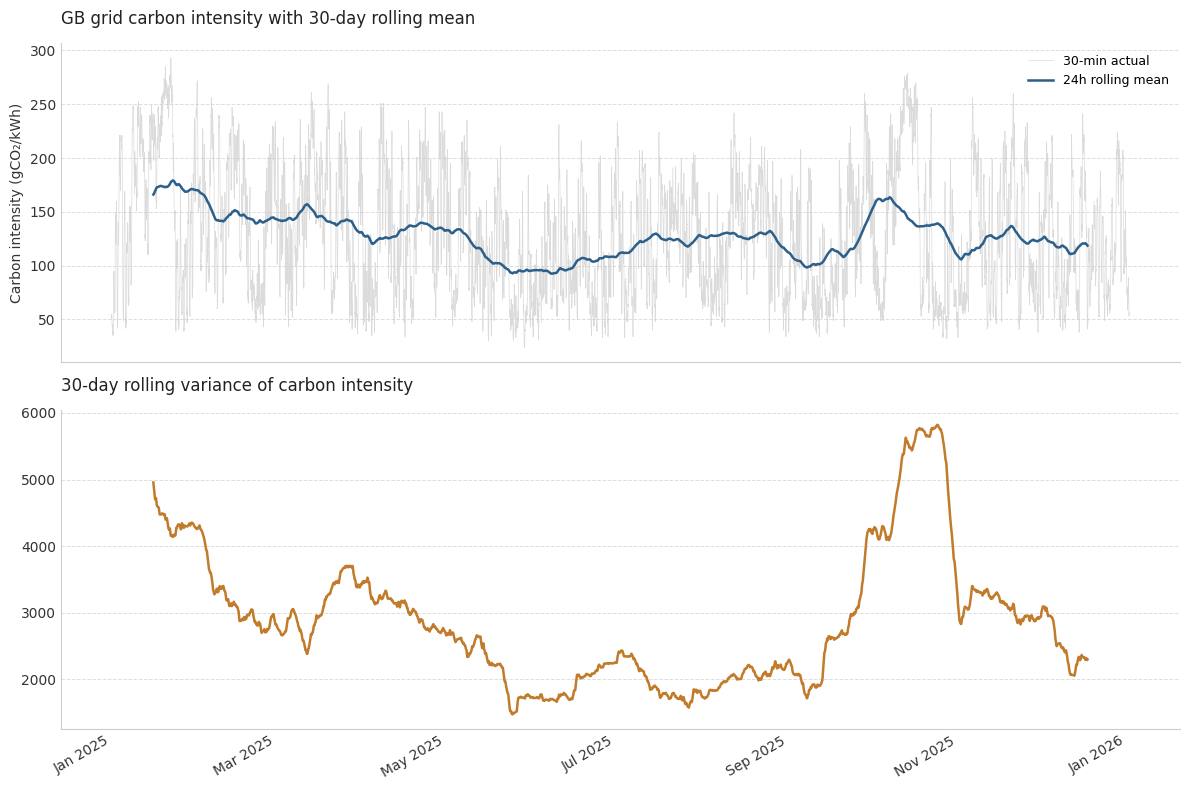

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
DATA_PATH = Path().resolve() / "Data" / "actual" / "2025.parquet"
actual_carbon_intensity = pd.read_parquet(DATA_PATH)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

actual_carbon_intensity["period_start"] = pd.to_datetime(actual_carbon_intensity["period_start"])
ci = actual_carbon_intensity.set_index("period_start")["actual"]

rolling_mean = ci.rolling(window=48*30, center=True, min_periods=48*30).mean().dropna()
rolling_var  = ci.rolling(window=48*30, center=True, min_periods=48*30).var().dropna()

# Top: actual carbon intensity with rolling mean
ax1.plot(ci.index, ci, color="#cccccc", linewidth=0.5, alpha=0.7, label="30-min actual")
ax1.plot(rolling_mean.index, rolling_mean, color="#2C5F8A", linewidth=1.8, label="24h rolling mean")
ax1.set_ylabel("Carbon intensity (gCO₂/kWh)", fontsize=10, color="#333333")
ax1.set_title("GB grid carbon intensity", fontsize=12, color="#222222", pad=14, loc="left")
ax1.legend(frameon=False, fontsize=9)

# Bottom: rolling variance
ax2.plot(rolling_var.index, rolling_var, color="#C17B2A", linewidth=1.8)
ax1.set_title("GB grid carbon intensity with 30-day rolling mean", fontsize=12, color="#222222", pad=14, loc="left")
ax2.set_title("30-day rolling variance of carbon intensity", fontsize=12, color="#222222", pad=14, loc="left")

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, color="#dddddd", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors="#333333", length=0)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

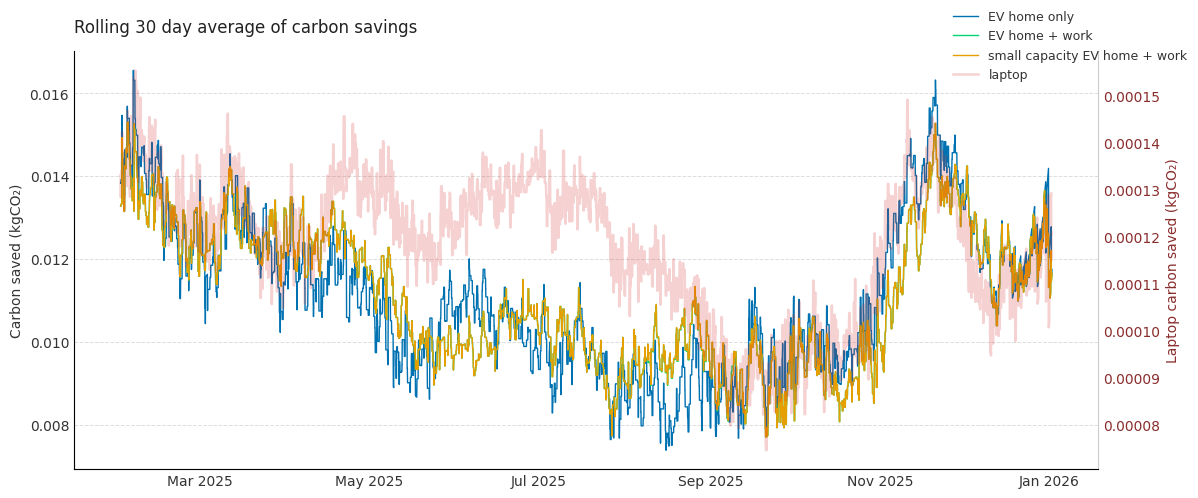

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#0072B2", "#00D672", "#E69F00", "#D4212134"]
WINDOW_SIZE, OFFSET = "30D", 30 * 49

for (label, load), color in zip(loads[:-1], colors[:-1]):
    carbon_savings = (load["carbon_cost_naive"] - load["carbon_cost_optimal"]).resample("30min").sum()
    rolling = carbon_savings.rolling(window=WINDOW_SIZE, center=True).mean().iloc[OFFSET:]
    ax.plot(rolling.index, rolling / 1000, label=label, color=color, linewidth=1)

ax2 = ax.twinx()
carbon_savings_laptop = (loads[-1][1]["carbon_cost_naive"] - loads[-1][1]["carbon_cost_optimal"]).resample("30min").sum()
rolling = carbon_savings_laptop.rolling(window=WINDOW_SIZE, center=True).mean().iloc[OFFSET:]
ax2.plot(rolling.index,
         rolling / 1000,
         color=colors[-1], linewidth=1.8, label="laptop")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

ax.yaxis.grid(True, linestyle="--", linewidth=0.7, color="#dddddd", zorder=0)
ax.set_axisbelow(True)

ax.set_ylabel("Carbon saved (kgCO₂)", fontsize=10, color="#333333")
ax.set_xlabel("")
ax.tick_params(axis="both", colors="#333333", length=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha="right")

ax2.set_ylabel("Laptop carbon saved (kgCO₂)", fontsize=10, color="#8A2C2C")
ax2.tick_params(axis="y", colors="#8A2C2C", length=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#cccccc")

ax.set_title("Rolling 30 day average of carbon savings",
             fontsize=12, color="#222222", pad=14, loc="left")

fig.legend(frameon=False, fontsize=9, labelcolor="#333333")

plt.tight_layout()
plt.show()


In [13]:
from arch.bootstrap import StationaryBootstrap, optimal_block_length
from statsmodels.stats.diagnostic import acorr_ljungbox

df_evhome48a = df_evhome48.resample("W", label="right").sum()
df_evwork48a = df_evwork48.resample("W", label="right").sum()
df_evwork_s48a = df_evwork_s48.resample("W", label="right").sum()
df_ltop48a = df_ltop48.resample("W", label="right").sum()

loads_aggregated = [
    ("EV home only", df_evhome48a),
    ("EV home + work", df_evwork48a),
    ("small capacity EV home + work", df_evwork_s48a),
    ("laptop", df_ltop48a),
]

results = []
for label, load in loads_aggregated:
    weekly_savings_pct = (
        (load["carbon_cost_naive"] - load["carbon_cost_optimal"])
        / load["carbon_cost_naive"] * 100
    ).values  # arch expects numpy array

    opt = optimal_block_length(weekly_savings_pct)
    block_length = int(opt["stationary"][0].round())

    bs = StationaryBootstrap(block_length, weekly_savings_pct)
    means = [data[0].mean() for data, _ in bs.bootstrap(1000)]
    ci_low, ci_high = np.percentile(means, [2.5, 97.5])

    ljung_p = acorr_ljungbox(weekly_savings_pct,52,return_df=True)["lb_pvalue"].min()

    results.append({
        "Load": label,
        "Mean (%)": weekly_savings_pct.mean(),
        "CI lower": ci_low,
        "CI upper": ci_high,
        "Block length (weeks)": block_length,
        "Ljung box test minimum p-value": ljung_p,
    })

df_bootstrap = pd.DataFrame(results).set_index("Load")
df_bootstrap.style.format({
    "Mean (%)": "{:.1f}%",
    "CI lower": "{:.1f}%",
    "CI upper": "{:.1f}%",
    "Block length (weeks)": "{:.0f}",
})

,Mean (%),CI lower,CI upper,Block length (weeks),Ljung box test minimum p-value
Load,,,,,
EV home only,43.5%,39.7%,47.2%,1,0.100438
EV home + work,48.2%,45.3%,51.4%,1,0.340598
small capacity EV home + work,48.1%,45.3%,51.0%,1,0.404018
laptop,13.9%,12.8%,15.1%,2,0.296373
